# GSEP Projects by Electric and Gas Utility

This notebook analyzes the distribution of Gas System Enhancement Program (GSEP) projects
across electric and gas utility service territories in Massachusetts.

Data source for utility territories: [MassGIS Public Utility Service Providers](https://www.mass.gov/info-details/massgis-data-public-utility-service-providers)

## Setup

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import contextily as ctx
from geopandas import sjoin

from src import (
    load_gsep_projects,
    load_electric_utility_providers,
    load_gas_utility_providers,
)

from config import WEB_MERCATOR

## Load Data

In [2]:
# Load GSEP projects
gsep_df = load_gsep_projects()
print(f"Loaded {len(gsep_df)} GSEP projects")

GSEP data already cached. Loading from disk...
Loaded Eversource: 398 records
Loaded Liberty: 292 records
Loaded Berkshire: 34 records
Loaded Eversource: 1445 records
Loaded Berkshire: 37 records
Loaded National Grid: 1238 records
Loaded Unitil: 230 records
Loaded National Grid: 100 records
Total GSEP records: 3774
Loaded 3774 GSEP projects


/workspaces/gsep_mapping/src/data_loader.py:205: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gsep_df = pd.concat(dfs, ignore_index=True)


In [3]:
# Load utility service territories
electric_df = load_electric_utility_providers()
gas_df = load_gas_utility_providers()

print(f"\nElectric utilities:")
print(electric_df['ELEC'].value_counts())

print(f"\nGas utilities:")
print(gas_df['GAS'].value_counts())

Electric utility data cached. Loading from disk...
Gas utility data cached. Loading from disk...

Electric utilities:
ELEC
National Grid (Massachusetts Electric)                                             159
Eversource Energy (NSTAR Electric)                                                 129
Eversource Energy (NSTAR Electric), National Grid (Massachusetts Electric)           8
Unitil (Fitchburg Gas & Electric)                                                    4
Reading Municipal Light Department                                                   3
Taunton Municipal Lighting Plant                                                     3
Middleborough Gas and Electric Department, Eversource Energy (NSTAR Electric)        2
Littleton Electric Light & Water Department                                          2
Hudson Light and Power Department                                                    2
Hull Municipal Lighting Plant                                                        1
Westfie

## GSEP Projects by Electric Utility Territory

Map showing GSEP project locations overlaid on electric utility service territories.

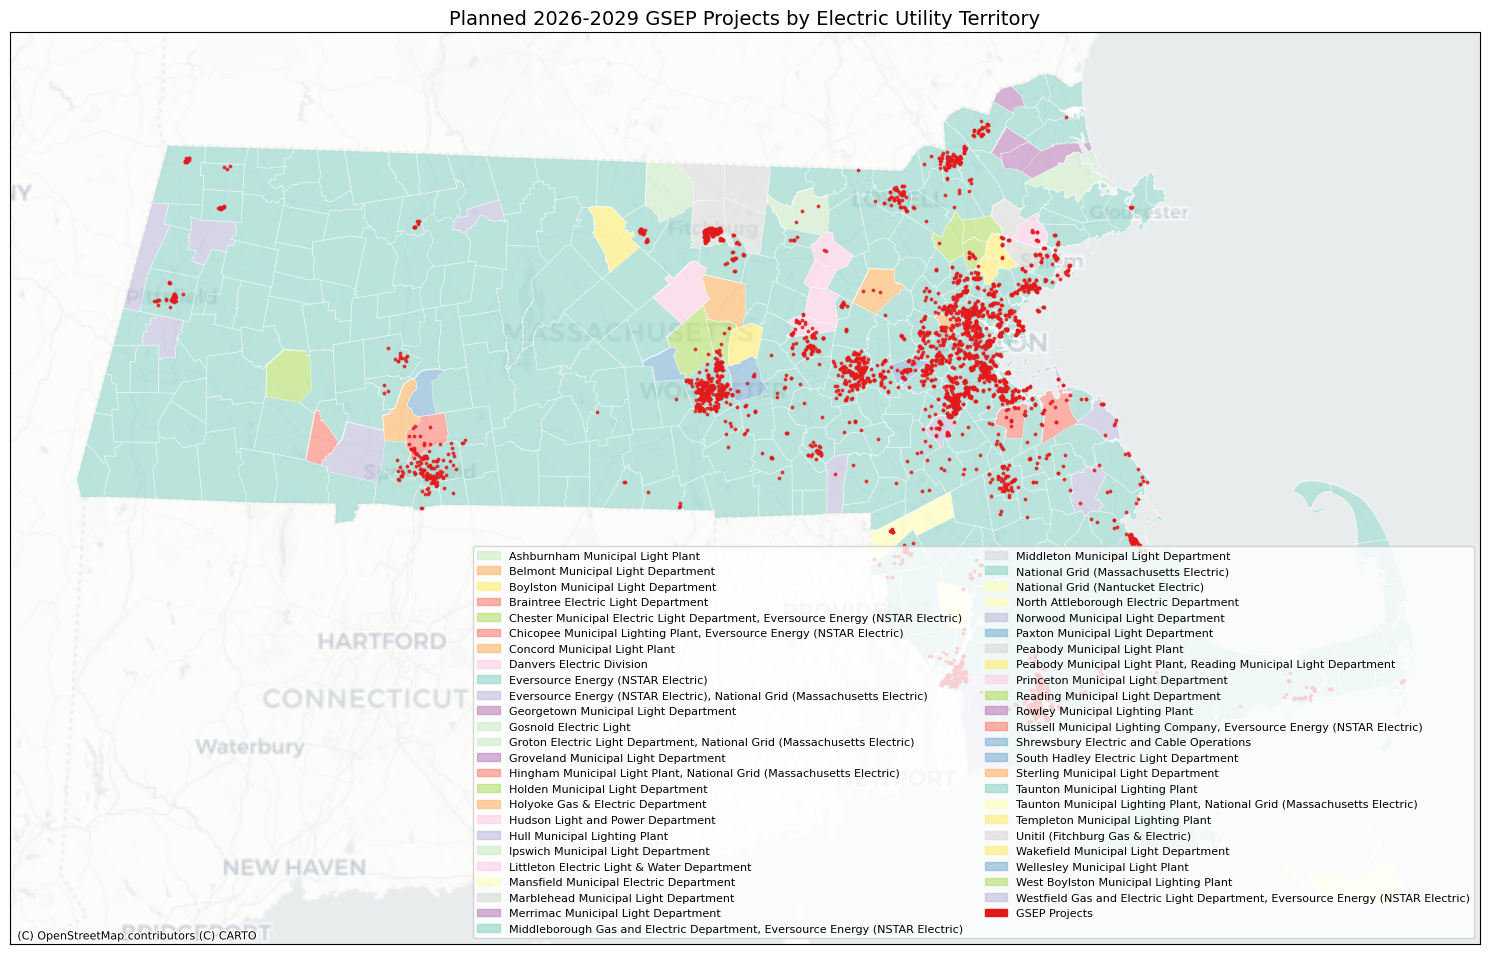

In [4]:
# Define color palette for electric utilities
electric_utilities = electric_df['ELEC'].unique()
electric_colors = plt.cm.Set3(np.linspace(0, 1, len(electric_utilities)))
electric_color_map = dict(zip(electric_utilities, electric_colors))

fig, ax = plt.subplots(1, 1, figsize=(15, 15), frameon=False)

# Project to Web Mercator
electric_proj = electric_df.to_crs(WEB_MERCATOR)
gsep_proj = gsep_df.to_crs(WEB_MERCATOR)

# Plot electric utility territories
for utility in electric_utilities:
    subset = electric_proj[electric_proj['ELEC'] == utility]
    color = electric_color_map[utility]
    subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5, alpha=0.6)

# Plot GSEP projects
gsep_proj.plot(ax=ax, color='#E31A1C', markersize=3, alpha=0.8, label='GSEP Projects')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.5)

# Create legend
legend_patches = [mpatches.Patch(color=electric_color_map[u], label=u, alpha=0.6) 
                  for u in sorted(electric_utilities)]
legend_patches.append(mpatches.Patch(color='#E31A1C', label='GSEP Projects'))
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, ncol=2)

ax.set_title('Planned 2026-2029 GSEP Projects by Electric Utility Territory', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

## Assign Utility Providers to GSEP Projects

Spatial join to determine which electric and gas utility territory each GSEP project falls within.

In [5]:
# Project GSEP to match utility CRS for spatial join
gsep_proj = gsep_df.to_crs(electric_df.crs)

# Spatial join with electric utilities
gsep_with_electric = sjoin(
    gsep_proj, 
    electric_df[['ELEC', 'geometry']], 
    how='left', 
    predicate='within'
)

# Handle any projects that didn't fall within a territory (use nearest)
gsep_with_electric['Electric_Utility'] = gsep_with_electric['ELEC'].fillna('Unknown')

# Spatial join with gas utilities
gsep_proj = gsep_df.to_crs(gas_df.crs)
gsep_with_gas = sjoin(
    gsep_proj, 
    gas_df[['GAS', 'geometry']], 
    how='left', 
    predicate='within'
)

# Combine both utility assignments
gsep_utilities = gsep_df.copy()
gsep_utilities['Electric_Utility'] = gsep_with_electric['ELEC'].fillna('Unknown').values
gsep_utilities['Gas_Utility'] = gsep_with_gas['GAS'].fillna('No Gas Service').values

print("GSEP Projects by Electric Utility:")
print(gsep_utilities['Electric_Utility'].value_counts())

print("\nGSEP Projects by Gas Utility:")
print(gsep_utilities['Gas_Utility'].value_counts())

GSEP Projects by Electric Utility:
Electric_Utility
Eversource Energy (NSTAR Electric)                                            1776
National Grid (Massachusetts Electric)                                        1548
Unitil (Fitchburg Gas & Electric)                                              204
Wellesley Municipal Light Plant                                                 28
Peabody Municipal Light Plant                                                   22
Norwood Municipal Light Department                                              21
Hudson Light and Power Department                                               20
Chicopee Municipal Lighting Plant, Eversource Energy (NSTAR Electric)           19
Eversource Energy (NSTAR Electric), National Grid (Massachusetts Electric)      16
Marblehead Municipal Light Department                                           16
Belmont Municipal Light Department                                              16
Braintree Electric Light Department

## GSEP Projects: Gas vs Electric Utility Heatmap

Heatmap showing the number of GSEP projects in each combination of gas and electric utility territory.

In [13]:
# Create cross-tabulation of gas and electric utilities
utility_crosstab = pd.crosstab(
    gsep_utilities['LDC'], 
    gsep_utilities['Electric_Utility'],
    margins=True,
    margins_name='Total'
)

print("Cross-tabulation of GSEP Projects by Gas and Electric Utility:")
utility_crosstab

Cross-tabulation of GSEP Projects by Gas and Electric Utility:


Electric_Utility,Belmont Municipal Light Department,Braintree Electric Light Department,"Chicopee Municipal Lighting Plant, Eversource Energy (NSTAR Electric)",Concord Municipal Light Plant,Danvers Electric Division,Eversource Energy (NSTAR Electric),"Eversource Energy (NSTAR Electric), National Grid (Massachusetts Electric)","Groton Electric Light Department, National Grid (Massachusetts Electric)","Hingham Municipal Light Plant, National Grid (Massachusetts Electric)",Holden Municipal Light Department,...,"Peabody Municipal Light Plant, Reading Municipal Light Department",Reading Municipal Light Department,Shrewsbury Electric and Cable Operations,Taunton Municipal Lighting Plant,"Taunton Municipal Lighting Plant, National Grid (Massachusetts Electric)",Unitil (Fitchburg Gas & Electric),Wakefield Municipal Light Department,Wellesley Municipal Light Plant,West Boylston Municipal Lighting Plant,Total
LDC,,,,,,,,,,,,,,,,,,,,,
Berkshire,0,0,0,0,0,46,0,0,0,0,...,0,0,0,0,0,0,0,0,0,71
Eversource,0,0,19,0,0,1114,13,0,0,2,...,0,0,6,10,1,0,0,0,6,1843
Liberty,0,0,0,0,0,0,3,0,0,0,...,0,0,0,0,0,0,0,0,0,292
National Grid,16,12,0,3,11,616,0,3,6,0,...,2,10,0,0,0,0,1,28,0,1338
Unitil,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,204,0,0,0,230
Total,16,12,19,3,11,1776,16,3,6,2,...,2,10,6,10,1,204,1,28,6,3774


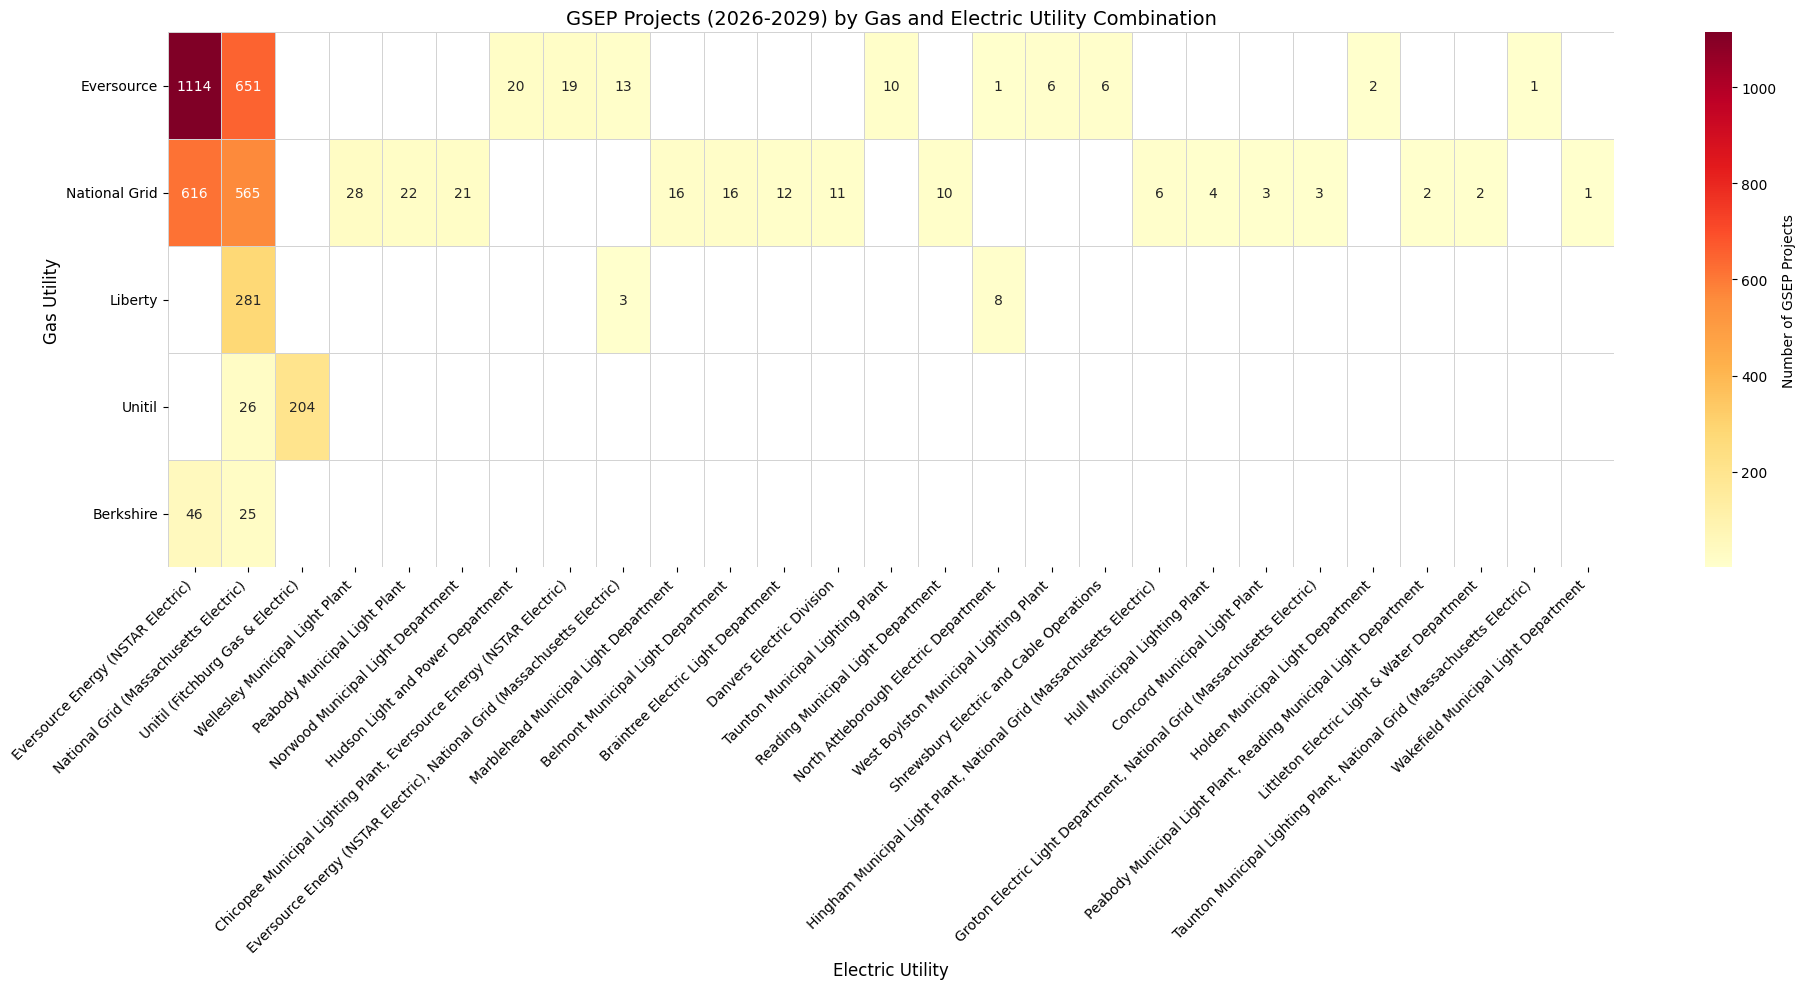

In [16]:
# Create heatmap without the totals row/column
utility_matrix = pd.crosstab(
    gsep_utilities['LDC'], 
    gsep_utilities['Electric_Utility']
)

# Sort by total counts for better visualization
row_order = utility_matrix.sum(axis=1).sort_values(ascending=False).index
col_order = utility_matrix.sum(axis=0).sort_values(ascending=False).index
utility_matrix = utility_matrix.loc[row_order, col_order]

# Create the heatmap
fig, ax = plt.subplots(figsize=(20, 10))

# Create mask for zero values to display them as white
mask = utility_matrix == 0

sns.heatmap(
    utility_matrix,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    mask=mask,
    linewidths=0.5,
    linecolor='lightgray',
    ax=ax,
    cbar_kws={'label': 'Number of GSEP Projects'}
)

ax.set_title('GSEP Projects (2026-2029) by Gas and Electric Utility Combination', fontsize=14)
ax.set_xlabel('Electric Utility', fontsize=12)
ax.set_ylabel('Gas Utility', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Summary Statistics

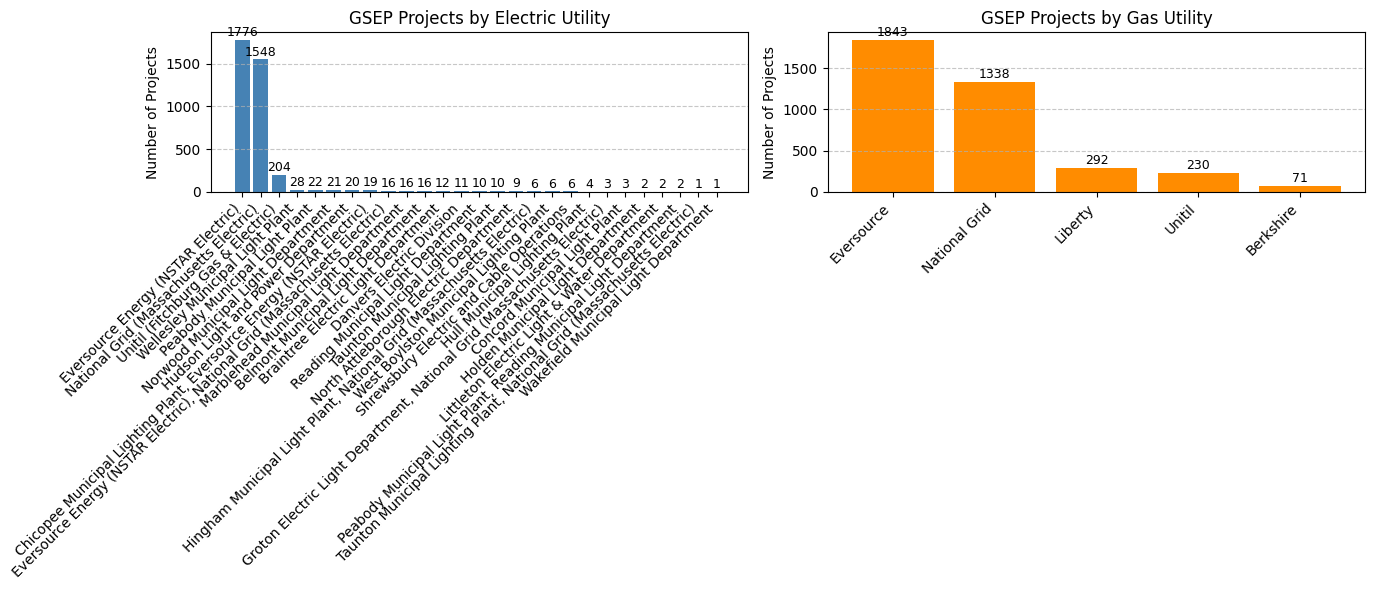

In [17]:
# Summary bar chart - GSEP by Electric Utility
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Electric utility counts
electric_counts = gsep_utilities['Electric_Utility'].value_counts()
ax1 = axes[0]
bars1 = ax1.bar(range(len(electric_counts)), electric_counts.values, color='steelblue')
ax1.set_xticks(range(len(electric_counts)))
ax1.set_xticklabels(electric_counts.index, rotation=45, ha='right')
ax1.set_title('GSEP Projects by Electric Utility')
ax1.set_ylabel('Number of Projects')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels
for bar, count in zip(bars1, electric_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', va='bottom', fontsize=9)

# Gas utility counts
gas_counts = gsep_utilities['LDC'].value_counts()
ax2 = axes[1]
bars2 = ax2.bar(range(len(gas_counts)), gas_counts.values, color='darkorange')
ax2.set_xticks(range(len(gas_counts)))
ax2.set_xticklabels(gas_counts.index, rotation=45, ha='right')
ax2.set_title('GSEP Projects by Gas Utility')
ax2.set_ylabel('Number of Projects')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels
for bar, count in zip(bars2, gas_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# Print summary
print("=" * 60)
print("GSEP Projects by Utility Analysis Summary")
print("=" * 60)
print(f"\nTotal GSEP Projects: {len(gsep_utilities)}")
print(f"\nProjects by Electric Utility:")
for utility, count in electric_counts.items():
    pct = count / len(gsep_utilities) * 100
    print(f"  {utility}: {count} ({pct:.1f}%)")

print(f"\nProjects by Gas Utility:")
for utility, count in gas_counts.items():
    pct = count / len(gsep_utilities) * 100
    print(f"  {utility}: {count} ({pct:.1f}%)")

# Top combinations
print(f"\nTop 10 Gas/Electric Utility Combinations:")
combo_counts = gsep_utilities.groupby(['Gas_Utility', 'Electric_Utility']).size().sort_values(ascending=False)
for (gas, elec), count in combo_counts.head(10).items():
    pct = count / len(gsep_utilities) * 100
    print(f"  {gas} / {elec}: {count} ({pct:.1f}%)")

GSEP Projects by Utility Analysis Summary

Total GSEP Projects: 3774

Projects by Electric Utility:
  Eversource Energy (NSTAR Electric): 1776 (47.1%)
  National Grid (Massachusetts Electric): 1548 (41.0%)
  Unitil (Fitchburg Gas & Electric): 204 (5.4%)
  Wellesley Municipal Light Plant: 28 (0.7%)
  Peabody Municipal Light Plant: 22 (0.6%)
  Norwood Municipal Light Department: 21 (0.6%)
  Hudson Light and Power Department: 20 (0.5%)
  Chicopee Municipal Lighting Plant, Eversource Energy (NSTAR Electric): 19 (0.5%)
  Eversource Energy (NSTAR Electric), National Grid (Massachusetts Electric): 16 (0.4%)
  Marblehead Municipal Light Department: 16 (0.4%)
  Belmont Municipal Light Department: 16 (0.4%)
  Braintree Electric Light Department: 12 (0.3%)
  Danvers Electric Division: 11 (0.3%)
  Reading Municipal Light Department: 10 (0.3%)
  Taunton Municipal Lighting Plant: 10 (0.3%)
  North Attleborough Electric Department: 9 (0.2%)
  Hingham Municipal Light Plant, National Grid (Massachusett